In [1]:
import pandas as pd

enriched = pd.read_parquet('../data/processed/enriched_events.parquet')
print(enriched.shape)
print(enriched.dtypes)
enriched.head()

(19150868, 18)
user_id                        object
timestamp         datetime64[us, UTC]
artist_name                    object
track_name                     object
next_timestamp    datetime64[us, UTC]
gap_seconds                   float64
is_new_session                  int32
session_id                      int32
is_skip                          bool
danceability                  float64
energy                        float64
valence                       float64
tempo                         float64
acousticness                  float64
loudness                      float64
popularity                    float64
track_genre                    object
match_type                     object
dtype: object


,user_id,timestamp,artist_name,track_name,next_timestamp,gap_seconds,is_new_session,session_id,is_skip,danceability,energy,valence,tempo,acousticness,loudness,popularity,track_genre,match_type
0,user_000004,2007-10-23 03:16:11+00:00,Radiohead,Nude,2007-10-23 03:22:55+00:00,404.0,0,329,False,0.516,0.342,0.167,128.378,0.832,-9.785,69.0,alt-rock,exact
1,user_000004,2007-10-23 03:22:55+00:00,Radiohead,Jigsaw Falling Into Place,2007-10-23 03:27:04+00:00,249.0,0,329,False,0.462,0.832,0.807,165.653,0.108,-6.085,69.0,alt-rock,exact
2,user_000004,2007-10-23 20:21:07+00:00,Amy Winehouse,Back To Black,2007-10-23 20:25:09+00:00,242.0,0,330,False,0.403,0.422,0.378,122.728,0.134,-13.964,81.0,soul,exact
3,user_000004,2007-10-23 20:30:51+00:00,Amy Winehouse,Back To Black,2007-10-23 20:34:52+00:00,241.0,0,330,False,0.403,0.422,0.378,122.728,0.134,-13.964,81.0,soul,exact
4,user_000004,2007-10-23 22:10:55+00:00,Al Green,How Can You Mend A Broken Heart,2007-10-23 22:17:22+00:00,387.0,0,331,False,0.448,0.421,0.367,146.427,0.507,-6.959,24.0,blues,exact


In [4]:
import os
print(os.getcwd())

D:\skip-behavior-analysis\notebooks


In [5]:
!dir /s /b enriched_events.parquet

File Not Found


In [6]:
df = pd.read_parquet('../data/processed/enriched_events.parquet')
print(df.shape)

(19150868, 18)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('data/processed/enriched_events.parquet')
print(df.shape)

In [9]:
import os
os.makedirs('outputs', exist_ok=True)

                 skip_rate  n_plays
position_bucket                    
1                 0.002132  1041883
2                 0.003734   899953
3                 0.002864   815024
4                 0.003777   748705
5                 0.003222   691810
6                 0.004057   642411
7                 0.003527   598445
8                 0.004270   559267
9                 0.003798   523486
10                0.004584   490356
11                0.004071   457899
12                0.004794   427589
13                0.004278   399754
14                0.004988   375120
15                0.004639   352664
16                0.005384   332487
17                0.005106   313973
18                0.005593   297171
19                0.005141   281286
20                0.012971  8901585


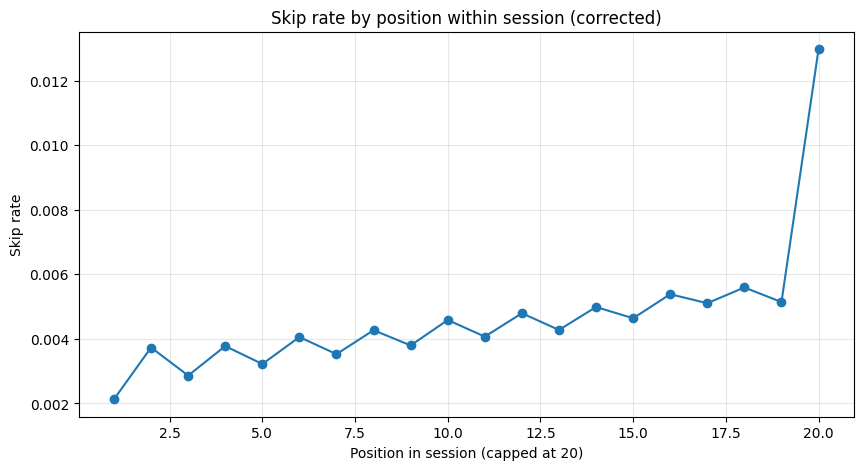

In [13]:
# Rank each track's position within its TRUE session (unique per user + session_id)
df = df.sort_values(['user_id', 'session_id', 'timestamp'])
df['session_position'] = df.groupby(['user_id', 'session_id']).cumcount() + 1

# Cap at a reasonable max so a few marathon sessions don't stretch the x-axis uselessly
MAX_POSITION = 20
df['position_bucket'] = df['session_position'].clip(upper=MAX_POSITION)

skip_by_position = df.groupby('position_bucket')['is_skip'].agg(['mean', 'count'])
skip_by_position.columns = ['skip_rate', 'n_plays']
print(skip_by_position)

plt.figure(figsize=(10, 5))
plt.plot(skip_by_position.index, skip_by_position['skip_rate'], marker='o')
plt.xlabel('Position in session (capped at 20)')
plt.ylabel('Skip rate')
plt.title('Skip rate by position within session (corrected)')
plt.grid(alpha=0.3)
plt.savefig('outputs/skip_rate_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# PLEASE BE FR: does the alternating pattern hold within a single user, or is it an artifact of aggregation?
sample_user = df[df['session_id'] == df['session_id'].iloc[0]]
print(sample_user[['session_position', 'is_skip', 'gap_seconds']].head(25))

          session_position  is_skip  gap_seconds
8349644                  1    False        690.0
17275387                 2    False        202.0
13345535                 3    False        240.0
5638301                  4    False      19192.0
3614671                  5    False        321.0
9825451                  6    False        252.0
17275388                 7    False        674.0
13345536                 8    False        260.0
15403109                 9    False      22647.0
9825452                 10    False        216.0
3614672                 11    False       4400.0
13345293                12    False        250.0
18543847                13    False      10264.0
9825453                 14    False        206.0
8349645                 15    False       1120.0
13345537                16    False        260.0
9825454                 17    False        238.0
17275389                18    False        141.0
17275390                19    False        141.0
9825455             

In [12]:
# Check: how many distinct users share this one session_id?
check_id = df['session_id'].iloc[0]
print(df[df['session_id'] == check_id]['user_id'].nunique())

992


      skip_rate  n_plays
hour                    
0      0.010462   750333
1      0.010277   683450
2      0.008702   646730
3      0.007109   608098
4      0.006552   564569
5      0.006179   517194
6      0.006334   484337
7      0.009159   489678
8      0.009084   526726
9      0.007902   591386
10     0.007404   666702
11     0.007452   730988
12     0.007546   781963
13     0.008809   851940
14     0.008511   922142
15     0.008696   992910
16     0.008570  1051174
17     0.008030  1083863
18     0.007922  1120495
19     0.007451  1132132
20     0.006980  1114398
21     0.007657  1049397
22     0.008174   949895
23     0.009288   840368


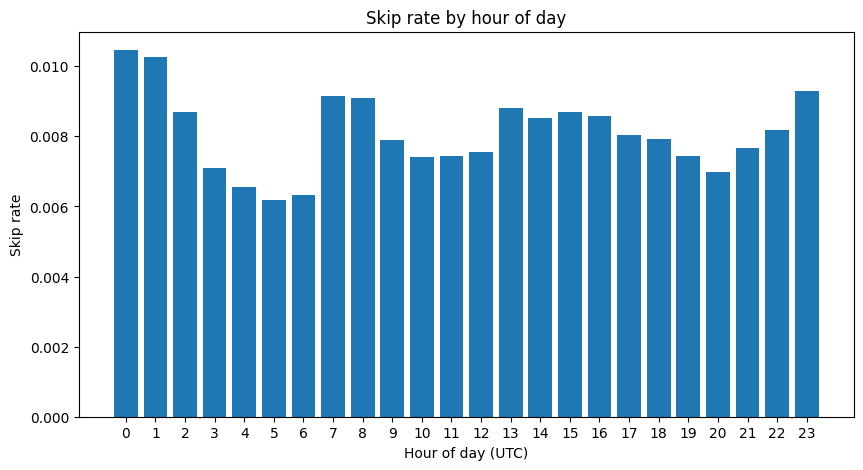

In [14]:
df['hour'] = df['timestamp'].dt.hour

skip_by_hour = df.groupby('hour')['is_skip'].agg(['mean', 'count'])
skip_by_hour.columns = ['skip_rate', 'n_plays']
print(skip_by_hour)

plt.figure(figsize=(10, 5))
plt.bar(skip_by_hour.index, skip_by_hour['skip_rate'])
plt.xlabel('Hour of day (UTC)')
plt.ylabel('Skip rate')
plt.title('Skip rate by hour of day')
plt.xticks(range(0, 24))
plt.savefig('outputs/skip_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

Matched subset: 1,340,422 rows (7.0% of total)


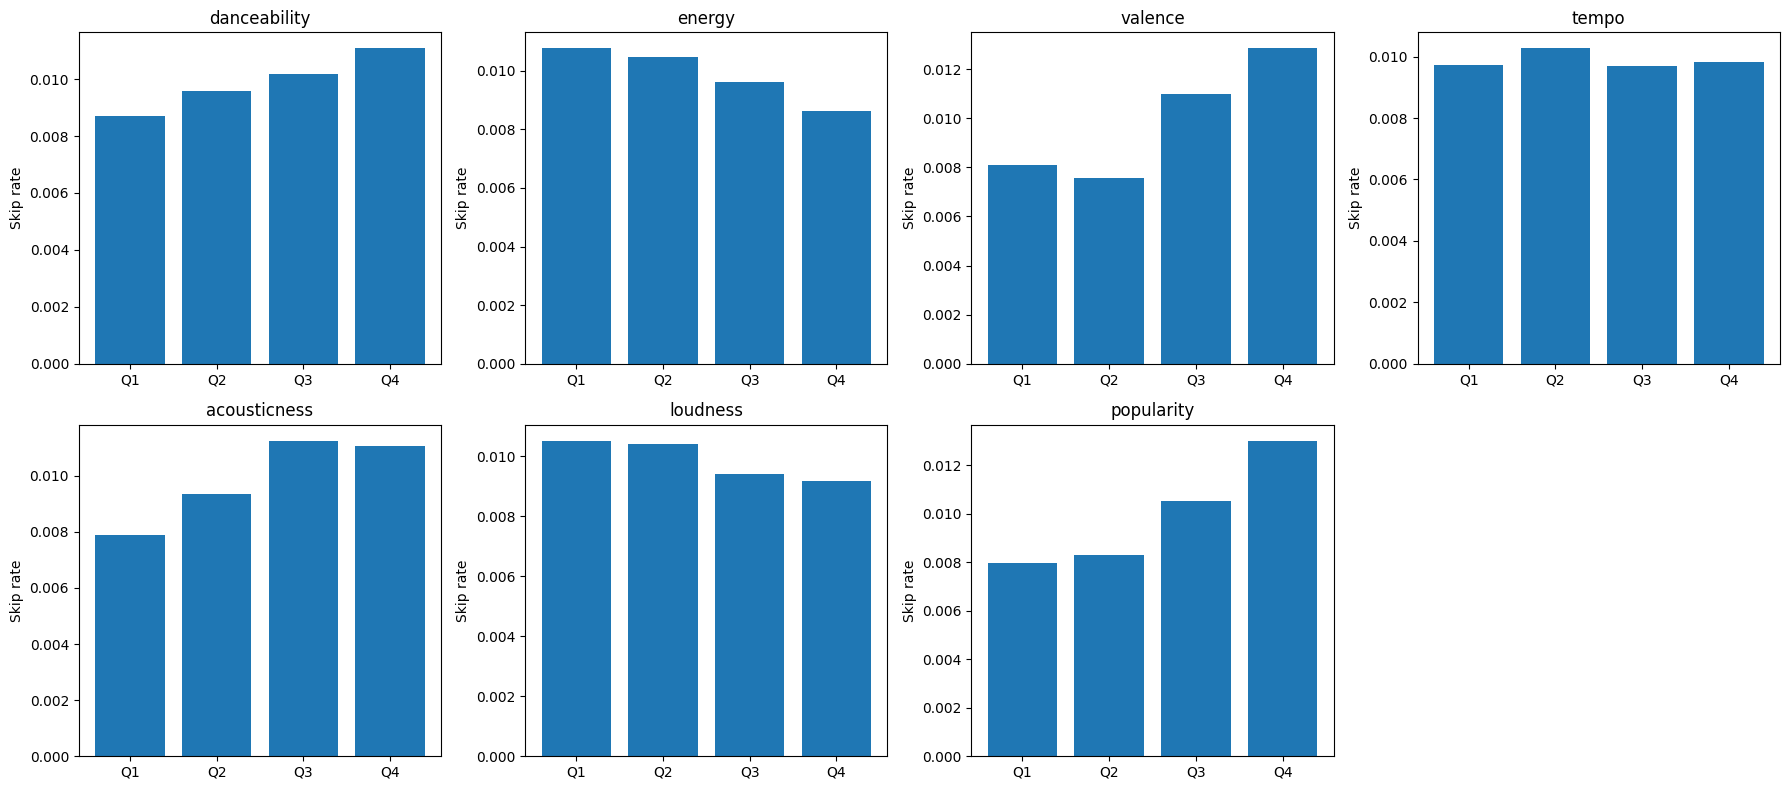

In [15]:
matched = df[df['match_type'].notna() & df['danceability'].notna()].copy()
print(f"Matched subset: {len(matched):,} rows ({len(matched)/len(df)*100:.1f}% of total)")

features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'loudness', 'popularity']

# Bin each feature into quartiles and compare skip rate across bins —
# more robust than a raw correlation given the 0.8% skip rate class imbalance
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    matched[f'{feat}_bin'] = pd.qcut(matched[feat], q=4, duplicates='drop')
    skip_by_feat = matched.groupby(f'{feat}_bin', observed=True)['is_skip'].mean()
    axes[i].bar(range(len(skip_by_feat)), skip_by_feat.values)
    axes[i].set_xticks(range(len(skip_by_feat)))
    axes[i].set_xticklabels([f'Q{j+1}' for j in range(len(skip_by_feat))])
    axes[i].set_title(feat)
    axes[i].set_ylabel('Skip rate')

axes[-1].axis('off')  # unused subplot slot
plt.tight_layout()
plt.savefig('outputs/skip_rate_by_features.png', dpi=150, bbox_inches='tight')
plt.show()